## Student Name: Gabriel Espinoza Rojas

## Student ID: 22176691

## Please do not add further imports. If you think an import is missing, please contact your moderator.

The notebook provides empty cells for your answer to give you guidance on the answer expected from you. You may add cells, but please note this may mean you go beyond what is expected from you and, if this results in unnecessary/unrelated content being added, may reduce your grade.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.neural_network import MLPClassifier
from sklearn import svm

from sklearn.model_selection import train_test_split
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV

from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
from skopt.utils import use_named_args

import sys
np.set_printoptions(threshold=sys.maxsize)
import time

# Task 1
## Task 1 Code
The below code is not necessarily complete or applicable to all tasks. Read and understand the code so that you can use wisely and adapt as required.

In [3]:
def plot_margin(X, y, clf):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=plt.cm.Paired)


    # plot the decision function
    ax = plt.gca()
    ax.set_aspect(aspect=1)
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # create grid to evaluate model
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = clf.decision_function(xy).reshape(XX.shape)

    # plot decision boundary and margins
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    # plot support vectors
    ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=100,
               linewidth=1, facecolors='none', edgecolors='k')

## Task 1 Instructions 

1. Load dataset Et3_Task1.csv and use a suitable plot to investigate the data.
    - You do not need to look at out-of-sample performance. Hence, there is no '_test' set. Use all available data for training.
2. Perform classification on this dataset using an SVM with linear kernel choosing the C parameter to obtain a hard margin.
    - In a plot containing the data, plot the SVM margins indicating the support vectors.
    - Extract the numerical representation of the support vectors from the trained model.
    - Obtain the performance of your model on training data.
3. Perform classification on this dataset using an SVM with linear kernel choosing the C parameter to obtain a soft margin with a maximum of 15 support vectors.
    - In a plot containing the data, plot the SVM margins indicating the support vectors.
    - Extract the numerical representation of each support vector from the trained model.
    - Obtain the performance of your model on training data.
    - Using information provided by your trained model, identify which of the support vectors lie inside the margin (i.e. are soft margin support vectors).
4. Answer the following questions:
      1. Explain how and why the width of the margin changes as you increase / decrease the C-parameter? Relate this to the Hinge loss error measure (including the regularisation term) used in SVMs. (100 words max)
    2. How and why does the width of the margin affect the expected generalisation abilities of the model? (100 words max)
    3. For the soft-margin model, provide the coordinates of the support vectors that do not violate the margin. (100 words max)

## Task 1 Answer
We suggest to stick to the number of cells provided below.

## 1. Load dataset Et3_Task1.csv and use a suitable plot to investigate the data.
    - You do not need to look at out-of-sample performance. Hence, there is no '_test' set. Use all available data for training.

(1001, 2)
(1001,)


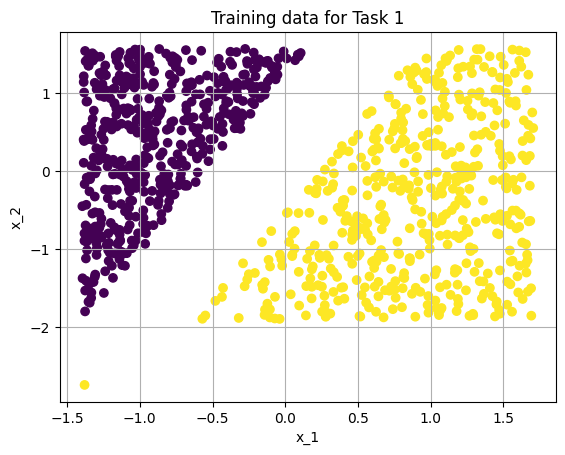

In [4]:
data_task1 = np.loadtxt("Et3_Task1.csv", delimiter=",")
X_Task1 = data_task1[:,0:2]
y_Task1 = data_task1[:,2]

print(np.shape(X_Task1))
print(np.shape(y_Task1))
plt.scatter(X_Task1[:, 0], X_Task1[:, 1], c=y_Task1)
plt.title("Training data for Task 1")
plt.xlabel("x_1")
plt.ylabel("x_2")
plt.grid()

### 2. Perform classification on this dataset using an SVM with linear kernel choosing the C parameter to obtain a hard margin.
    - In a plot containing the data, plot the SVM margins indicating the support vectors.
    - Extract the numerical representation of the support vectors from the trained model.
    - Obtain the performance of your model on training data.

Linear kernel with hard margin (C=100)


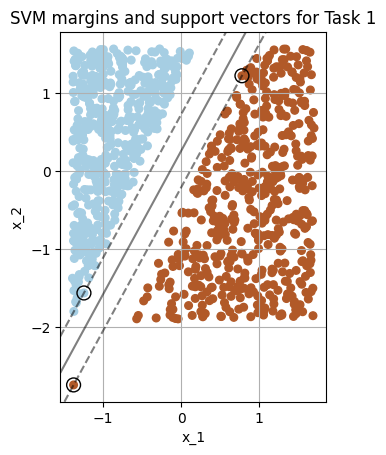

Numerical representation of the support vectors:
Support Vector 1: -1.2472, -1.5625
Support Vector 2: 0.7804, 1.2247
Support Vector 3: -1.3800, -2.7426
Performance:
Accuracy: 100.00%
E_in: 0.0000


In [5]:
#default 1.0, but we want to use a hard margin SVM, so we set C to a very large value
hard_margin_C = 100

linear_support_vector_classifier_hard_margin_task1 = svm.SVC(C=hard_margin_C, kernel='linear', degree=3, gamma='scale', coef0=0.0, shrinking=True, probability=False, tol=0.001, 
                                                  cache_size=200, class_weight=None, verbose=False, max_iter=-1, decision_function_shape='ovr', break_ties=False, random_state=0)

linear_support_vector_classifier_hard_margin_task1.fit(X_Task1, y_Task1)

print(f"Linear kernel with hard margin (C={hard_margin_C})")
plot_margin(X_Task1, y_Task1, linear_support_vector_classifier_hard_margin_task1)
plt.title("SVM margins and support vectors for Task 1")
plt.xlabel("x_1")
plt.ylabel("x_2")
plt.grid()
plt.show()


support_vectors = linear_support_vector_classifier_hard_margin_task1.support_vectors_
print("Numerical representation of the support vectors:")
for i, support_vector in enumerate(support_vectors):
    print(f"Support Vector {i+1}: {support_vector[0]:.4f}, {support_vector[1]:.4f}")


print("Performance:")
# check accuracy // E_in
accuracy = np.mean(linear_support_vector_classifier_hard_margin_task1.predict(X_Task1) == y_Task1)       
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"E_in: {1 - accuracy:.4f}")

### 3. Perform classification on this dataset using an SVM with linear kernel choosing the C parameter to obtain a soft margin with a maximum of 15 support vectors.
    - In a plot containing the data, plot the SVM margins indicating the support vectors.
    - Extract the numerical representation of each support vector from the trained model.
    - Obtain the performance of your model on training data.
    - Using information provided by your trained model, identify which of the support vectors lie inside the margin (i.e. are soft margin support vectors).

Linear kernel with soft margin (C=0.7)


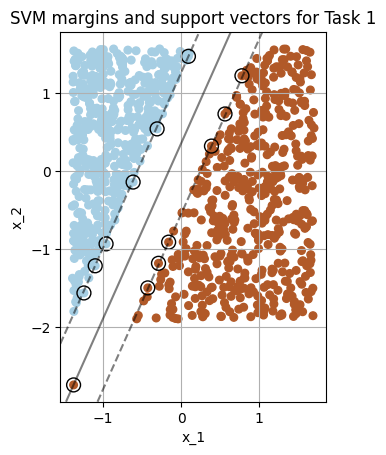

Numerical representation of the support vectors:
Support Vector 1: -0.6160, -0.1395
Support Vector 2: -1.1022, -1.2138
Support Vector 3: -0.3084, 0.5429
Support Vector 4: 0.0935, 1.4738
Support Vector 5: -0.9632, -0.9325
Support Vector 6: -1.2472, -1.5625
Support Vector 7: 0.7804, 1.2247
Support Vector 8: -0.1602, -0.9105
Support Vector 9: -1.3800, -2.7426
Support Vector 10: -0.4279, -1.4975
Support Vector 11: 0.3893, 0.3224
Support Vector 12: -0.2904, -1.1821
Support Vector 13: 0.5628, 0.7342
Performance:
Accuracy: 100.00%
E_in: 0.0000
15 support vectors max? True


In [6]:
#default 1.0, but we want to use a soft margin SVM, so we set C to a very small value
soft_margin_C = 0.70

linear_support_vector_classifier_soft_margin_task1 = svm.SVC(C=soft_margin_C, kernel='linear', degree=3, gamma='scale', coef0=0.0, shrinking=True, probability=False, tol=0.001, 
                                                  cache_size=200, class_weight=None, verbose=False, max_iter=-1, decision_function_shape='ovr', break_ties=False, random_state=0)


linear_support_vector_classifier_soft_margin_task1.fit(X_Task1, y_Task1)


print(f"Linear kernel with soft margin (C={soft_margin_C})")
plot_margin(X_Task1, y_Task1, linear_support_vector_classifier_soft_margin_task1)
plt.title("SVM margins and support vectors for Task 1")
plt.xlabel("x_1")
plt.ylabel("x_2")
plt.grid()
plt.show()


support_vectors = linear_support_vector_classifier_soft_margin_task1.support_vectors_
print("Numerical representation of the support vectors:")
for i, support_vector in enumerate(support_vectors):
    print(f"Support Vector {i+1}: {support_vector[0]:.4f}, {support_vector[1]:.4f}")


print("Performance:")
# check accuracy // E_in
accuracy = np.mean(linear_support_vector_classifier_soft_margin_task1.predict(X_Task1) == y_Task1)       
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"E_in: {1 - accuracy:.4f}")

print("15 support vectors max?", 15 >= len(linear_support_vector_classifier_soft_margin_task1.support_vectors_))

### 4. Answer the following questions:
    1. Explain how and why the width of the margin changes as you increase / decrease the C-parameter? Relate this to the Hinge loss error measure (including the regularisation term) used in SVMs. (100 words max)


    2. How and why does the width of the margin affect the expected generalisation abilities of the model? (100 words max)

    
    3. For the soft-margin model, provide the coordinates of the support vectors that do not violate the margin. (100 words max)

# Task 2
## Task 2 code

In [7]:
def plot_margin(X, y, clf):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=plt.cm.Paired)


    # plot the decision function
    ax = plt.gca()
    ax.set_aspect(aspect=1)
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # create grid to evaluate model
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = clf.decision_function(xy).reshape(XX.shape)

    # plot decision boundary and margins
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    # plot support vectors
    ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=100,
               linewidth=1, facecolors='none', edgecolors='k')

## Task 2 Instructions 

1. Load dataset Et3_Task2_train and Et3_Task2_test.csv and use a suitable plot to investigate the training data
2. Train a SVM model with a suitable kernel but otherwise all hyper parameters as default
3. Visualise the support vectors and margin
4. Train a SVM model and optimise appropriate hyper parameters
5. Visualise the support vectors and margin
6. Explain which model is the best model using the results from step 2-5 to provide as much evidence as possible for your claim (100 words max).

## Task 2 Answer
We suggest to stick to the number of cells provided below.

### 1. Load dataset Et3_Task2_train and Et3_Task2_test.csv and use a suitable plot to investigate the training data.

(335, 2)
(335,)


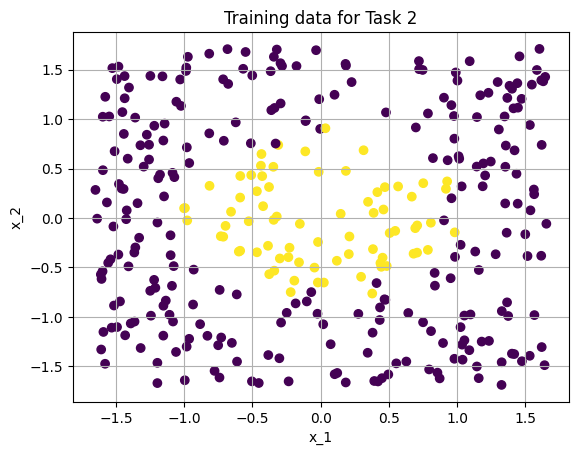

(165, 2)
(165,)


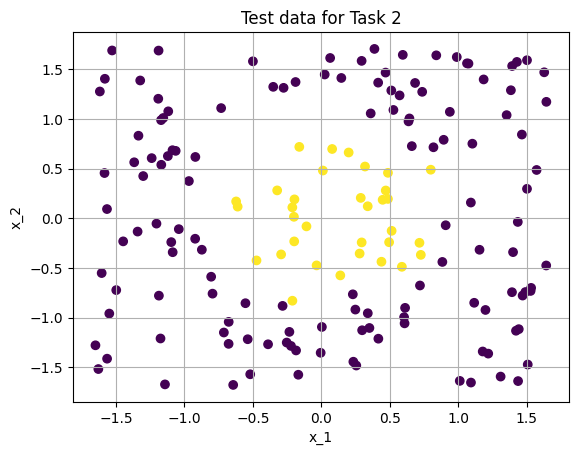

In [8]:
training_data_task2 = np.loadtxt("Et3_Task2_train.csv", delimiter=",")
X_Task2_training = training_data_task2[:,0:2]
y_Task2_training = training_data_task2[:,2]

print(np.shape(X_Task2_training))
print(np.shape(y_Task2_training))
plt.scatter(X_Task2_training[:, 0], X_Task2_training[:, 1], c=y_Task2_training)
plt.title("Training data for Task 2")
plt.xlabel("x_1")
plt.ylabel("x_2")
plt.grid()
plt.show()

test_data_task2 = np.loadtxt("Et3_Task2_test.csv", delimiter=",")
X_Task2_test = test_data_task2[:,0:2]
y_Task2_test = test_data_task2[:,2]

print(np.shape(X_Task2_test))
print(np.shape(y_Task2_test))
plt.scatter(X_Task2_test[:, 0], X_Task2_test[:, 1], c=y_Task2_test)
plt.title("Test data for Task 2")
plt.xlabel("x_1")
plt.ylabel("x_2")
plt.grid()

### 2. Train a SVM model with a suitable kernel but otherwise all hyper parameters as default

In [9]:
# Radial basis function kernel (rbf, also called Gaussian kernel), suitable kernel with default parameters
support_vector_classifier_suitable_kernel_only_task2 = svm.SVC(kernel='rbf', random_state=0)

support_vector_classifier_suitable_kernel_only_task2.fit(X_Task2_training, y_Task2_training)
print("How many support vectors?", len(support_vector_classifier_suitable_kernel_only_task2.support_vectors_))

How many support vectors? 75


### 3. Visualise the support vectors and margin

Performance:
Accuracy: 96.42%
E_in: 0.0358


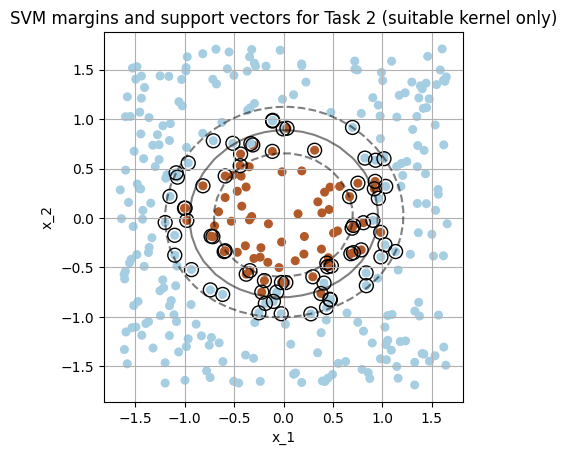

In [10]:
plot_margin(X_Task2_training, y_Task2_training, support_vector_classifier_suitable_kernel_only_task2)
plt.title("SVM margins and support vectors for Task 2 (suitable kernel only)")
plt.xlabel("x_1")
plt.ylabel("x_2")
plt.grid()


print("Performance:")
# check accuracy // E_in
accuracy = np.mean(support_vector_classifier_suitable_kernel_only_task2.predict(X_Task2_training) == y_Task2_training)       
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"E_in: {1 - accuracy:.4f}")

Performance:
Accuracy: 96.36%
E_out: 0.0364


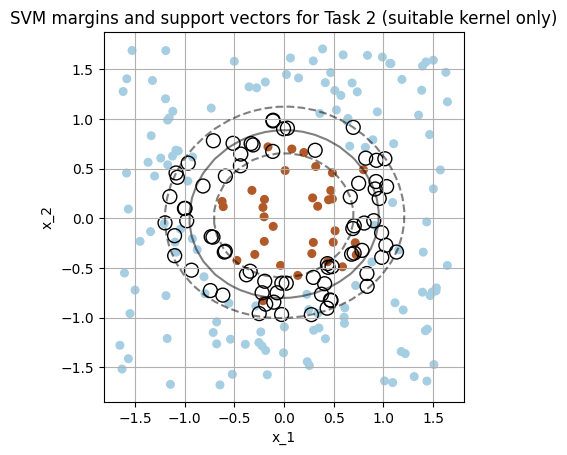

In [11]:
plot_margin(X_Task2_test, y_Task2_test, support_vector_classifier_suitable_kernel_only_task2)
plt.title("SVM margins and support vectors for Task 2 (suitable kernel only)")
plt.xlabel("x_1")
plt.ylabel("x_2")
plt.grid()


print("Performance:")
# check accuracy // E_out
accuracy = np.mean(support_vector_classifier_suitable_kernel_only_task2.predict(X_Task2_test) == y_Task2_test)       
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"E_out: {1 - accuracy:.4f}")

### 4. Train a SVM model and optimise appropriate hyper parameters

In [12]:
# Radial basis function kernel (rbf, also called Gaussian kernel), suitable kernel with default parameters
#support_vector_classifier_tuned_hyperparameters_task2 = svm.SVC(C=10, kernel='rbf', degree=5, gamma='scale', coef0=0.0, shrinking=True, probability=False, tol=0.001, cache_size=200,
#                                                                class_weight=None, verbose=False, max_iter=-1, decision_function_shape='ovr', break_ties=False, random_state=0)

bayes_search = BayesSearchCV(
    svm.SVC(random_state=0),
    {
        'C': Real(1e-6, 1e+6, prior='log-uniform'),
        'kernel': Categorical(['rbf']), #'linear', 'rbf', 'poly'
        #'degree': Integer(1, 8),
        'gamma': Real(1e-6, 1e+1, prior='log-uniform'), #Categorical(['scale', 'auto']),
        'tol': Real(1e-4, 1e-2, prior='log-uniform'),
        'cache_size': Integer(100, 500),
        #'max_iter': Integer(-1, 1000), # tones of warning on console
    },
    n_iter=50,
    #cv=StratifiedKFold(n_splits=5),
    random_state=0, #verbose=0
)


# executes bayesian optimization
_ = bayes_search.fit(X_Task2_training, y_Task2_training)

In [13]:
print(bayes_search.score(X_Task2_training, y_Task2_training))
print(bayes_search.score(X_Task2_test, y_Task2_test))

bayes_search.best_params_

0.9701492537313433
0.9636363636363636


OrderedDict([('C', 9855.783780142783),
             ('cache_size', 100),
             ('gamma', 0.015548017900598758),
             ('kernel', 'rbf'),
             ('tol', 0.01)])

In [14]:
# Radial basis function kernel (rbf, also called Gaussian kernel), suitable kernel with default parameters
#support_vector_classifier_tuned_hyperparameters_task2 = svm.SVC(C=10, kernel='rbf', degree=5, gamma='scale', coef0=0.0, shrinking=True, probability=False, tol=0.001, cache_size=200,
#                                                                class_weight=None, verbose=False, max_iter=-1, decision_function_shape='ovr', break_ties=False, random_state=0)

grid_search = GridSearchCV(
    svm.SVC(random_state=0),
    param_grid={
        'C': [1, 10, 100, 1000],
        'kernel': ['rbf'], #'linear', 'rbf', 'poly'
        #'degree': [1, 2, 3, 4, 5, 6, 7, 8],
        'gamma': [0.001, 0.01, 0.1, 1], 
        'tol': [1e-4, 1e-3, 1e-2],
        'cache_size': [100, 200, 300, 400, 500],
        #'max_iter': Integer(-1, 1000), # tones of warning on console
    }
)


# executes grid search optimization
_ = grid_search.fit(X_Task2_training, y_Task2_training)
grid_search.best_params_

{'C': 1000, 'cache_size': 100, 'gamma': 0.1, 'kernel': 'rbf', 'tol': 0.0001}

In [15]:
print(grid_search.score(X_Task2_training, y_Task2_training))
print(grid_search.score(X_Task2_test, y_Task2_test))

bayes_search.best_params_

0.9731343283582089
0.9696969696969697


OrderedDict([('C', 9855.783780142783),
             ('cache_size', 100),
             ('gamma', 0.015548017900598758),
             ('kernel', 'rbf'),
             ('tol', 0.01)])

In [16]:
# Radial basis function kernel (rbf, also called Gaussian kernel), suitable kernel with default parameters
support_vector_classifier_tuned_hyperparameters_task2 = svm.SVC(C=10, kernel='rbf', degree=5, gamma='scale', coef0=0.0, shrinking=True, probability=False, tol=0.001, cache_size=200,
                                                                class_weight=None, verbose=False, max_iter=-1, decision_function_shape='ovr', break_ties=False, random_state=0)

support_vector_classifier_tuned_hyperparameters_task2.fit(X_Task2_training, y_Task2_training)
print("How many support vectors?", len(support_vector_classifier_tuned_hyperparameters_task2.support_vectors_))

How many support vectors? 38


### 5. Visualise the support vectors and margin

Performance:
Accuracy: 97.01%
E_in: 0.0299


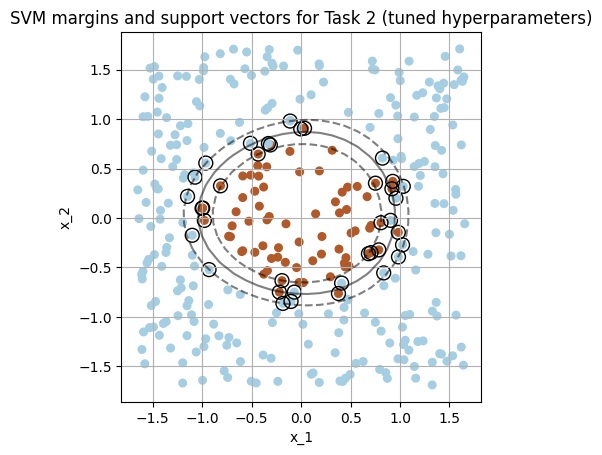

In [17]:
print("Performance:")
# check accuracy // E_in
accuracy = np.mean(support_vector_classifier_tuned_hyperparameters_task2.predict(X_Task2_training) == y_Task2_training)       
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"E_in: {1 - accuracy:.4f}")


plot_margin(X_Task2_training, y_Task2_training, support_vector_classifier_tuned_hyperparameters_task2)
plt.title("SVM margins and support vectors for Task 2 (tuned hyperparameters)")
plt.xlabel("x_1")
plt.ylabel("x_2")
plt.grid()

How many support vectors? 38
Performance:
Accuracy: 97.58%
E_out: 0.0242


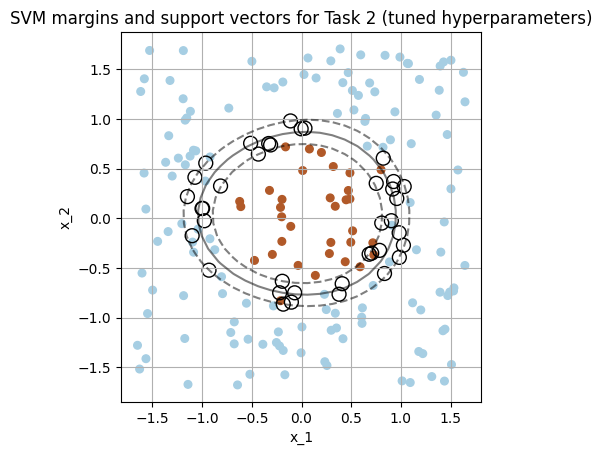

In [18]:
plot_margin(X_Task2_test, y_Task2_test, support_vector_classifier_tuned_hyperparameters_task2)
plt.title("SVM margins and support vectors for Task 2 (tuned hyperparameters)")
plt.xlabel("x_1")
plt.ylabel("x_2")
plt.grid()

print("How many support vectors?", len(support_vector_classifier_tuned_hyperparameters_task2.support_vectors_))

print("Performance:")
# check accuracy // E_out
accuracy = np.mean(support_vector_classifier_tuned_hyperparameters_task2.predict(X_Task2_test) == y_Task2_test)       
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"E_out: {1 - accuracy:.4f}")

### 6. Explain which model is the best model using the results from step 2-5 to provide as much evidence as possible for your claim (100 words max).

Results from kernel-only model:
 - E in 0.0358
 - Accuracy 96.42%
 - E out 0.0365
 - Accuracy 96.36%
 - SVs: 75

Results from tuned model:
 - E in 0.0299
 - Accuracy 97.01%
 - E out 0.0242
 - Accuracy 97.58%
 - SVs: 38

# Task 3
## Task 3 code
This wrapper is required in below BayesSearchCV for a neural network to combine the two layer arguments (or more if you wish to experiment with more than two layers) into the single hidden_layer_sizes hyper-parameter.

In [19]:
class MLPWrapper(BaseEstimator, ClassifierMixin):
    
    def __init__(self, 
                 layer1=100, 
                 layer2=100, 
                 alpha=0.0001, 
                 activation='relu', 
                 learning_rate_init=1e-3,
                 early_stopping = False,
                 n_iter_no_change = 10,
                solver = 'adam'):
        self.layer1 = layer1
        self.layer2 = layer2
        self.alpha = alpha
        self.activation = activation
        self.learning_rate_init = learning_rate_init
        self.early_stopping = early_stopping
        self.n_iter_no_change = n_iter_no_change
        self.solver = solver

    def fit(self, X, y):
        model = MLPClassifier(
            hidden_layer_sizes=[self.layer1, self.layer2],
            alpha=self.alpha,
            max_iter = 1000,
            activation = self.activation,
            learning_rate_init = self.learning_rate_init,
            early_stopping = self.early_stopping,
            n_iter_no_change = self.n_iter_no_change,
            solver = self.solver,
            random_state=10
        )
        model.fit(X, y)
        self.model = model
        return self

    def predict(self, X):
        return self.model.predict(X)

    def score(self, X, y):
        return self.model.score(X, y)
    
    def get_model():
        return self.model

In [ ]:
# Example use of BayesSearchCV to search a large search space whilst keeping compute requirements in check

optSVM1_lin = BayesSearchCV(
    svm.SVC(),
    {
      'C': Real(1e-3, 1e+3, prior='log-uniform'),
        'kernel': Categorical(['linear']),
    },
    n_iter=40,
)

In [21]:
# Example use of BayesSearchCV with the MLPWrapper to vary the layer sizes

optNN1 = BayesSearchCV(
    estimator=MLPWrapper(),
    search_spaces={
        'layer1': Integer(1, 100),
        'layer2': Integer(1, 100)
    },
    n_iter=40,
)

## Task 3 Instructions
1. Load dataset Et3_Task3_train and Et3_Task3_test.csv.
2. Train a SVM model with a suitable kernel but otherwise all hyper parameters as default
    - Print the performance on training data
    - Print the performance on test data
3. Train a SVM model and optimise appropriate hyper parameters
    - Try 2 searches: try both Grid-based searches and Bayesian searches. Note that these can take considerable time so set them up correctly first with a small number of feature dimensions / iterations to check correctness. Then increase the number of features dimensions / iterations and wait. You may wish to get a sense of train times with a relatively small number of iterations first.  
    - Keep track of the time required for the full search
    - Print the performance on training data
    - Print the performance on test data
    - Try to achieve a score of > 0.85 on test data for at least one of the searches
4. Train a neural network with a suitable activation function and guestimates for the hidden layer sizes but otherwise all hyper parameters as default
    - Print the performance on training data
    - Print the performance on test data
5. Train a neural network and optimise appropriate hyper parameters
    - Use 2 searches: try both Grid-based searches and Bayesian searches. Note that these can take considerable time so set them up correctly first with a small number of feature dimensions / iterations to check correctness. Then increase the number of features dimensions / iterations and wait. You may wish to get a sense of train times with a relative small number of iterations first.  
    - Keep track of the time required for the full search
    - Print the performance on training data
    - Print the performance on test data
    - Try to achieve a score of > 0.84 on test data for at least one of the searches
6. Answer the following questions:
   1. Explain the difference in performance between the two search strategies for each of the models (SVM and Neural Network). Point out any deviations (if any) from what you expected and potential fixes. If you ended up not using one of the search strategies for either step 3 or step 5, explain why (200 words max).
   2. Explain the major considerations when choosing between Bayesian and grid-based hyper-parameter optimisation (100 words max).
   2. When choosing the kernel type is part of SVM optimisation, what is key in reducing compute time as much as possible (100 words max)?  
    

## Task 3 Answer
We suggest to stick to the number of cells provided below.

### 1. Load dataset Et3_Task3_train and Et3_Task3_test.csv

(1750, 20)
(1750,)


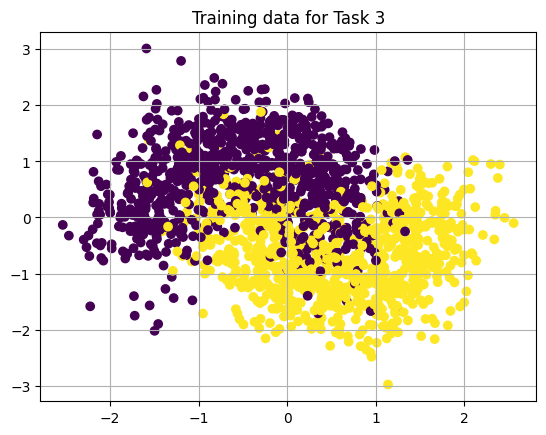

(750, 20)
(750,)


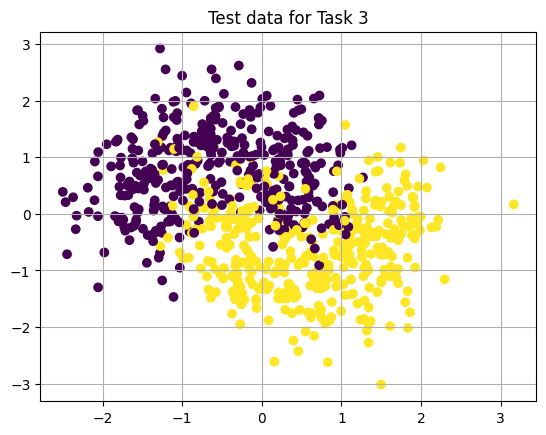

In [22]:
training_data_task3 = np.loadtxt("Et3_Task3_train.csv", delimiter=",")
X_Task3_training = training_data_task3[:,0:20]
y_Task3_training = training_data_task3[:,20]

print(np.shape(X_Task3_training))
print(np.shape(y_Task3_training))
plt.scatter(X_Task3_training[:, 0], X_Task3_training[:, 1], c=y_Task3_training)
plt.title("Training data for Task 3")
plt.grid()
plt.show()

test_data_task3 = np.loadtxt("Et3_Task3_test.csv", delimiter=",")
X_Task3_test = test_data_task3[:,0:20]
y_Task3_test = test_data_task3[:,20]

print(np.shape(X_Task3_test))
print(np.shape(y_Task3_test))
plt.scatter(X_Task3_test[:, 0], X_Task3_test[:, 1], c=y_Task3_test)
plt.title("Test data for Task 3")
plt.grid()

### 2. Train a SVM model with a suitable kernel but otherwise all hyper parameters as default
    - Print the performance on training data
    - Print the performance on test data

In [23]:
# Radial basis function kernel (rbf, also called Gaussian kernel), suitable kernel with default parameters
support_vector_classifier_suitable_kernel_only_task3 = svm.SVC(kernel='rbf', random_state=0)

support_vector_classifier_suitable_kernel_only_task3.fit(X_Task3_training, y_Task3_training)
print("How many support vectors?", len(support_vector_classifier_suitable_kernel_only_task3.support_vectors_))

print("Performance:")
# check accuracy // E_in
accuracy = np.mean(support_vector_classifier_suitable_kernel_only_task3.predict(X_Task3_training) == y_Task3_training)       
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"E_in: {1 - accuracy:.4f}")

print("Performance:")
# check accuracy // E_out
accuracy = np.mean(support_vector_classifier_suitable_kernel_only_task3.predict(X_Task3_test) == y_Task3_test)       
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"E_out: {1 - accuracy:.4f}")

How many support vectors? 920
Performance:
Accuracy: 90.86%
E_in: 0.0914
Performance:
Accuracy: 84.53%
E_out: 0.1547


### 3. Train a SVM model and optimise appropriate hyper parameters
    - Use 2 searches: try both Grid-based searches and Bayesian searches. Note that these can take considerable time so set them up correctly first with a small number of feature dimensions / iterations to check correctness. Then increase the number of features dimensions / iterations and wait. You may wish to get a sense of train times with a relative small number of iterations first.  
    - Keep track of the time required for the full search
    - Print the performance on training data
    - Print the performance on test data

In [24]:
#Search 1:

bayes_search = BayesSearchCV(
    svm.SVC(random_state=0),
    {
        'C': Real(1e-6, 1e+6, prior='log-uniform'),
        'kernel': Categorical(['rbf']), #'linear', 'rbf', 'poly'
        #'degree': Integer(1, 8),
        'gamma': Real(1e-6, 1e+1, prior='log-uniform'), #Categorical(['scale', 'auto']),
        'tol': Real(1e-4, 1e-2, prior='log-uniform'),
        'cache_size': Integer(100, 500),
        'max_iter': Integer(10,1000), # tones of warning on console
    },
    n_iter=50,
    #cv=StratifiedKFold(n_splits=5),
    random_state=0, #verbose=0
)

# executes grid search optimization
_ = bayes_search.fit(X_Task3_training, y_Task3_training)

print(bayes_search.score(X_Task3_training, y_Task3_training))
print(bayes_search.score(X_Task3_test, y_Task3_test))

bayes_search.best_params_


c:\Users\Admin\Documents\UL\master\CE6002 - Artificial Intelligence and Machine Learning\e-tivity3\.venv\lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=860).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Admin\Documents\UL\master\CE6002 - Artificial Intelligence and Machine Learning\e-tivity3\.venv\lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=860).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Admin\Documents\UL\master\CE6002 - Artificial Intelligence and Machine Learning\e-tivity3\.venv\lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=860).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Admin\Documents\UL\master\CE6002 - Artificial Intelligence and Machine Learning\e-tivity3\.venv\l

0.8634285714285714
0.8586666666666667


OrderedDict([('C', 0.41212463760440593),
             ('cache_size', 483),
             ('gamma', 0.021020371040072268),
             ('kernel', 'rbf'),
             ('max_iter', 1000),
             ('tol', 0.00788067564671161)])

In [25]:
#Search 2

grid_search = GridSearchCV(
    svm.SVC(random_state=0),
    param_grid={
        'C': [1, 10, 100, 1000],
        'kernel': ['rbf'], #'linear', 'rbf', 'poly'
        #'degree': [1, 2, 3, 4, 5, 6, 7, 8],
        'gamma': [0.001, 0.01, 0.1, 1], 
        'tol': [1e-4, 1e-3, 1e-2],
        'cache_size': [100, 200, 300, 400, 500],
        'max_iter': [1000], # tones of warning on console
    }
)

# executes grid search optimization
_ = grid_search.fit(X_Task3_training, y_Task3_training)

print(grid_search.score(X_Task3_training, y_Task3_training))
print(grid_search.score(X_Task3_test, y_Task3_test))

grid_search.best_params_

c:\Users\Admin\Documents\UL\master\CE6002 - Artificial Intelligence and Machine Learning\e-tivity3\.venv\lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Admin\Documents\UL\master\CE6002 - Artificial Intelligence and Machine Learning\e-tivity3\.venv\lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Admin\Documents\UL\master\CE6002 - Artificial Intelligence and Machine Learning\e-tivity3\.venv\lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\Admin\Documents\UL\master\CE6002 - Artificial Intelligence and Machine Learning\e-tivity3\.ven

0.8514285714285714
0.852


{'C': 10,
 'cache_size': 100,
 'gamma': 0.001,
 'kernel': 'rbf',
 'max_iter': 1000,
 'tol': 0.001}

### 4. Train a neural network with a suitable activation function and guestimates for the hidden layer sizes but otherwise all hyper parameters as default
    - Print the performance on training data
    - Print the performance on test data

In [26]:
mlp_activation_function_and_hidden_sizes_only_task3 = MLPWrapper(layer1=100, layer2=100, activation='relu')

mlp_activation_function_and_hidden_sizes_only_task3.fit(X_Task3_training, y_Task3_training)

print("Performance on training data:")
# check accuracy // E_in
accuracy = mlp_activation_function_and_hidden_sizes_only_task3.score(X_Task3_training, y_Task3_training)
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"E_in: {1 - accuracy:.4f}")


print("Performance on test data:")
# check accuracy // E_out
accuracy = mlp_activation_function_and_hidden_sizes_only_task3.score(X_Task3_test, y_Task3_test)
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"E_out: {1 - accuracy:.4f}")

Performance on training data:
Accuracy: 100.00%
E_in: 0.0000
Performance on test data:
Accuracy: 80.53%
E_out: 0.1947


### 5. Train a neural network and optimise appropriate hyper parameters
    - Use 2 searches: try both Grid-based searches and Bayesian searches. Note that these can take considerable time so set them up correctly first with a small number of feature dimensions / iterations to check correctness. Then increase the number of features dimensions / iterations and wait. You may wish to get a sense of train times with a relative small number of iterations first.  
    - Keep track of the time required for the full search
    - Print the performance on training data
    - Print the performance on test data

In [ ]:
#Search 1

"""
valid parameters are: 
['activation', 'alpha', 'early_stopping', 
'layer1', 'layer2', 'learning_rate_init', 
'n_iter_no_change', 'solver']

"""

bayes_search = BayesSearchCV(
    estimator=MLPWrapper(),
    search_spaces={   
        #'activation': Categorical(['identity', 'relu', 'logistic', 'tanh']),
        'alpha': Real(1e-4, 1e-2, prior='log-uniform'),
        'early_stopping': Categorical([False, True]),
        'layer1': Integer(1, 100),
        'layer2': Integer(1, 100),
        'learning_rate_init':  Real(1e-6, 1e+1, prior='log-uniform'), #Categorical(['constant', 'adaptive']),
        'n_iter_no_change': Integer(1, 1000), # tones of warning on console
        'solver': Categorical(['adam', 'sgd', 'lbfgs'])
    },
    n_iter=500,
    #cv=StratifiedKFold(n_splits=5),
    random_state=0, #verbose=0
)

# executes grid search optimization
_ = bayes_search.fit(X_Task3_training, y_Task3_training)

print(bayes_search.score(X_Task3_training, y_Task3_training))
print(bayes_search.score(X_Task3_test, y_Task3_test))

bayes_search.best_params_

c:\Users\Admin\Documents\UL\master\CE6002 - Artificial Intelligence and Machine Learning\e-tivity3\.venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Admin\Documents\UL\master\CE6002 - Artificial Intelligence and Machine Learning\e-tivity3\.venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Admin\Documents\UL\master\CE6002 - Artificial Intelligence and Machine Learning\e-tivity3\.venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Admin\Documents\UL\master\CE6002 - Artificial Intell

In [ ]:
#Search 2

grid_search = GridSearchCV(
    MLPWrapper(),
    param_grid={
        'layer1': [1, 10, 100, 1000],
        'layer2': [1, 10, 100, 1000],
        'activation': ['relu', 'tanh', 'sigmoid'],
        'alpha': [1e-4, 1e-3, 1e-2],
        'learning_rate_init': [1e-4, 1e-3, 1e-2],
        #'max_iter': [100, 500, 1000], # tones of warning on console
    },
    
)

# executes grid search optimization
_ = grid_search.fit(X_Task3_training, y_Task3_training)

print(grid_search.score(X_Task3_training, y_Task3_training))
print(grid_search.score(X_Task3_test, y_Task3_test))

grid_search.best_params_

c:\Users\Admin\Documents\UL\master\CE6002 - Artificial Intelligence and Machine Learning\e-tivity3\.venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Admin\Documents\UL\master\CE6002 - Artificial Intelligence and Machine Learning\e-tivity3\.venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Admin\Documents\UL\master\CE6002 - Artificial Intelligence and Machine Learning\e-tivity3\.venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Admin\Documents\UL\master\CE6002 - Artificial Intell

6. Answer the following questions:
   1. Explain the difference in performance between the two search strategies for each of the models (SVM and Neural Network). Point out any deviations (if any) from what you expected and potential fixes. If you ended up not using one of the search strategies for either step 3 or step 5, explain why (200 words max).
   2. Explain the major considerations when choosing between Bayesian and grid-based hyper-parameter optimisation (100 words max).
   2. When choosing the kernel type is part of SVM optimisation, what is key in reducing compute time as much as possible (100 words max)?  

# Reflection

Clearly describe the changes you have made based on your peers' work and feedback (100 words max).
Describe your understanding of:
1. How hyper-parameters effect complexity and what our goal is in tuning hyper parameters (100 words max).
2. What aspects of your machine learning model determine whether a grid search or a Bayesian search is most appropriate, and why (150 words max).